[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/05_classes_basics.ipynb)

# 📓 Notebook 5 (fast track) — Classes & Object-Oriented Programming

> **Module:** Python Fundamentals · **Estimated time:** ~90 min · **Difficulty:** Beginner

This is a **gentle, intuition-first** introduction to object-oriented programming (OOP). We assume you're comfortable with variables, loops, conditionals, functions, lists, and dicts — but that classes are new. For every concept we'll ask **"why do we need this?"** *before* **"how do we write it?"**, lean on real-world analogies, draw a quick diagram, and only then show the Python.

> 🧭 **Mental models we'll use throughout.** A **class is a blueprint** (a house plan, a cookie cutter, a car factory); an **instance is the concrete thing** built from it (the actual house, cookie, car). **Attributes** are what an object *knows about itself*; **methods** are what an object *can do*. Keep these four pictures in mind and OOP stops being mysterious.

> 🏎️ *The canonical [`01_foundations/06_classes_and_oop.ipynb`](../01_foundations/06_classes_and_oop.ipynb) adds the special* dunder *methods (`__repr__`, `__eq__`) and the `@dataclass` shortcut — open it once you've finished here.*

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Explain why** OOP exists — the maintenance pain that loose functions + dicts create as a program grows.
2. **Use the blueprint ↔ instance mental model**, and avoid the classic "a class *is* an object" confusion.
3. **Define a class** with a constructor (`__init__`), **instance attributes**, and **methods** — and read `self` fluently.
4. **Distinguish** instance attributes from class attributes, and methods from plain functions.
5. **Use inheritance** (and its many names: parent/child, base/derived, super/subclass), **override** methods, and use **`super()`** / **`super().__init__()`** correctly — including *why* the parent constructor isn't called automatically.
6. **Recognise OOP in the wild** — PyTorch, scikit-learn, FastAPI — and write your own `fit`/`transform` and `fit`/`predict` classes.

## ✅ Prerequisites

Notebooks 1–4. You should be comfortable with functions, default arguments, lists, and dicts.

## 1. Why classes? — the problem *before* the solution

Let's not start with syntax. Let's start with a **real situation that gets painful**, so that when classes show up they feel like relief rather than ceremony.

You're tracking customers for a small SaaS business. The obvious first move is a dict:

In [39]:
customer = {
    "name": "Acme Inc.",
    "monthly_revenue": 14823.4567,
    "is_active": True,
}
print(customer["name"])


Acme Inc.


That works fine. But the *behaviour* you want to attach (compute annual revenue, deactivate the account, check whether the customer is high-value) ends up scattered across free-standing functions:


In [40]:
def annual_revenue(c):
    return c["monthly_revenue"] * 12

def deactivate(c):
    c["is_active"] = False

def is_high_value(c, threshold=10_000):
    return c["monthly_revenue"] >= threshold

print(annual_revenue(customer))         # 177881.4804
print(is_high_value(customer))          # True


177881.4804
True


That works for *one* customer. Now imagine a hundred of them, six months of edits, and three teammates. Three problems start to bite — and they show up the same way whether you're modelling **customers, students, bank accounts, or vehicles**:

1. **The data and the behaviour drift apart.** Someone adds a `monthly_revenue_eur` field and forgets to update `annual_revenue()`. The function silently returns the wrong number — nothing tells you.
2. **The logic is scattered.** To understand "what is a customer and what can it do?", you have to hunt through a pile of free-standing functions that *happen* to take a customer dict.

> 💡 **The core idea.** What we *want* is one place that says: *"a customer **has** these pieces of data and **can do** these things."* That single bundle — data **and** the behaviour that belongs with it — is exactly what a **class** gives you. Everything that operates on a customer lives *inside* the customer.

## 2. The big idea — a class is a blueprint

Before any code, get the one picture that makes everything else click:

> **A class is a *blueprint*. An instance is a *concrete thing* built from that blueprint.**

The same relationship has many everyday names — they all mean the same split:

| The blueprint (the **class**) | The concrete thing (the **instance**) |
|---|---|
| 🏠 An architect's house **plan** | the actual **house** you can walk into |
| 🍪 A cookie **cutter** | each **cookie** it stamps out |
| 🏭 A car **factory** | each individual **car** that rolls off the line |

You design the blueprint **once**; you build **many** concrete things from it. Each built thing has *its own* data, but they all *share* the same set of behaviours.

```
  class Customer:                ← THE BLUEPRINT (defined once)
      __init__(name, revenue)        the rule for building one
      annual_revenue()               a behaviour every customer has

              │  "build me one"  (call Customer(...))
              ▼
  ┌────────────────────┐   ┌────────────────────┐   ┌────────────────────┐
  │  acme  (instance)  │   │  beta  (instance)  │   │  cara  (instance)  │
  │  name = "Acme"     │   │  name = "Beta"     │   │  name = "Cara"     │
  │  rev  = 14823.46   │   │  rev  = 980.00     │   │  rev  = 50000.00   │
  └────────────────────┘   └────────────────────┘   └────────────────────┘
       three separate objects · same blueprint · each its own data
```

> 🚫 **Misconception #1 — "a class *is* an object."**
> A **class is a blueprint**, not an object. The **objects** are the **instances** you build from it (`acme`, `beta`, `cara`). You can have one class and a million instances. (Trivia: in Python even the class itself is technically an object — but for learning, hold the clean split: *class = blueprint, instance = object*.)

## 3. Your first class — and *many* instances from it

Now the syntax — but only after the picture above. Here's the customer record rewritten as a class. Read it top to bottom; we'll unpack every piece in the next sections.

> **Concept first:** we're writing the *blueprint*. Defining a class doesn't create any customers — just like drawing a house plan doesn't build a house. Building happens when we *call* `Customer(...)`.

In [41]:
class Customer:
    """A small SaaS customer."""

    def __init__(self, name, monthly_revenue, is_active=True):
        # Constructor — runs when you write `Customer(...)`.
        self.name             = name
        self.monthly_revenue  = monthly_revenue
        self.is_active        = is_active

    def annual_revenue(self):
        return self.monthly_revenue * 12

    def deactivate(self):
        self.is_active = False

    def is_high_value(self, threshold=10_000):
        return self.monthly_revenue >= threshold
             # False


In [42]:
acme = Customer("Acme Inc.", 14823.4567)
print(acme.name)                  # Acme Inc.
print(acme.annual_revenue())      # 177881.4804
print(acme.is_high_value())       # True
acme.deactivate()
print(acme.is_active)

Acme Inc.
177881.4804
True
False


Three syntactic things to absorb:

1. **`class ClassName:`** opens the blueprint. By convention class names are `CapitalCase`.
2. **`__init__(self, ...)`** is the **constructor**. Python calls it for you when you write `Customer(...)`. Its job is to set up the instance's initial state by assigning to `self.something`.
3. **`self`** is the *instance the method is being called on*. When you write `acme.annual_revenue()`, Python silently rewrites that to `Customer.annual_revenue(acme)` — `acme` becomes `self` inside the method body.

> 🎯 **Intuition.** `self` looks weird the first ten times. Read it as **"this particular instance"**. `self.name` means "the `name` attribute of *this* customer", as opposed to `name` (a local variable).


**One blueprint → many instances.** The whole point: from the *one* `Customer` class we can stamp out as many independent customers as we like. Each carries its own data; all of them share the same behaviour.

In [43]:
# Build THREE customers from the same blueprint
acme = Customer("Acme Inc.", 14_823.46)
beta = Customer("Beta LLC",     980.00)
cara = Customer("Cara Co.",  50_000.00)

for c in [acme, beta, cara]:
    # same method, called on different objects -> different data each time
    print(f"{c.name:<10} annual = {c.annual_revenue():>12,.2f}   high-value? {c.is_high_value()}")


Acme Inc.  annual =   177,881.52   high-value? True
Beta LLC   annual =    11,760.00   high-value? False
Cara Co.   annual =   600,000.00   high-value? True


```
        Customer  (ONE blueprint)
            │ build 3
   ┌────────┼────────┐
   ▼        ▼        ▼
  acme     beta     cara          ← three independent instances (objects)
```

Each line above ran the *same* `annual_revenue()` method, but on a *different object*, so it used that object's own `monthly_revenue`. That "shared behaviour, separate data" is the heart of OOP.

## 4. The constructor `__init__` — guaranteeing a valid start

**Why does `__init__` exist?** Picture building a customer *without* a constructor: you'd create a blank object and then remember to set every field by hand, every single time —

```python
acme = Customer()
acme.name = "Acme Inc."         # easy to forget one...
acme.monthly_revenue = 14823.46
# acme.is_active = True         # ...oops, forgot this — now acme.is_active raises AttributeError
```

That's exactly the "scattered, error-prone setup" problem from Section 1, reborn. The **constructor** fixes it: `__init__` is the method Python runs **automatically** the moment you write `Customer(...)`. Its one job is to make sure **every** new instance starts life **complete and valid**.

```
   Customer("Acme Inc.", 14823.46)
            │
            ▼   Python automatically calls...
   __init__(self, name="Acme Inc.", monthly_revenue=14823.46)
            │   ...which fills in the new object's attributes:
            ▼
   self.name = "Acme Inc." · self.monthly_revenue = 14823.46 · self.is_active = True
```

Read `__init__` as *"**init**ialise a freshly-built object."* You never call it directly — writing the class name with parentheses, `Customer(...)`, triggers it for you.

One subtlety trips up everyone: inside the constructor, `name` appears twice and the two are **not** the same thing.

### Two different things called `name` — parameter vs attribute

Look closely at the constructor — the word `name` appears twice, and they are **not the same thing**:

```python
def __init__(self, name):   # ← (1) the PARAMETER
    self.name = name        # ← (2) the ATTRIBUTE   = (1) the parameter
```

| | `name` (parameter) | `self.name` (attribute) |
|---|---|---|
| What it is | A **local variable** of `__init__` | A piece of the **object's own state** |
| Lives where | Only inside the constructor | Inside the object |
| Lifespan | **Disappears** when `__init__` finishes | **Persists** for the object's whole life |
| After creation | `name` is gone | `acme.name` still works |

The line `self.name = name` is the bridge: it **copies the temporary parameter into a permanent attribute on the object.** After the constructor returns, the parameter `name` is gone — but `acme.name` lives on inside `acme`.


## 5. Understanding `self` — "this particular object"

`self` is the single biggest stumbling block for OOP beginners, so let's slow right down.

**The intuition:** when an object runs one of its methods, `self` is the object **pointing at itself and saying "me."** `self.name` means *"the `name` belonging to **this** object"* — as opposed to some other customer's name, or a loose local variable.

When you write `acme.annual_revenue()`, Python quietly rewrites it to `Customer.annual_revenue(acme)` — it **passes the object in front of the dot as the first argument**. That argument lands in the parameter we conventionally call `self`. So:

```
   acme.annual_revenue()
        └──── Python turns this into ────►  Customer.annual_revenue(acme)
                                                                    │
                                                          self  ◄───┘   (self IS acme)
```

That's the whole trick. `self` is not magic and not a keyword — it's just the name of that first parameter. The next cell proves it by deliberately calling it `banana`.

### `self` is not a keyword — it's just a parameter name

The biggest surprise for beginners: **`self` is not special syntax.** It's an ordinary parameter, and *you* named it. The only reason it's always called `self` is universal convention — Python itself doesn't care. The cell below proves it by naming the first parameter `banana` instead:


In [5]:
# ⚠️ Educational ONLY — this works, but NEVER write real code like this.
class CustomerWeird:
    def __init__(banana, name):     # "banana" plays the role of self
        banana.name = name          # store on the object that was passed in

c = CustomerWeird("ACME Corp")
print(c.name)                       # ACME Corp — works fine!

# The lesson: `self` is just the *name* of the first parameter — the object
# Python automatically passes in. By convention we always call it `self`.


ACME Corp


And here's the proof that `self` really *is* the object you called the method on — plus the two equivalent call forms side by side:

In [6]:
acme   = Customer("ACME Corp",  10_000)
globex = Customer("Globex Inc",  5_000)

# 1️⃣ The two call forms are EQUIVALENT — Python rewrites the first into the second:
print(acme.annual_revenue())            # 120000
print(Customer.annual_revenue(acme))    # 120000  ← self=acme made explicit, same result

# 2️⃣ Same method, different object, different data:
print(globex.annual_revenue())          # 60000

# 3️⃣ `self` really IS the object you called the method on — prove it with `is`:
class Probe:
    def who_am_i(self):
        return self                     # hand back whatever self is

p = Probe()
print(p.who_am_i() is p)                # True — `self` inside the method is literally `p`


120000
120000
60000
True


### Visualising memory — each object carries its own state

After creating two customers, memory holds **two independent objects**. The method is shared (it lives on the class, once); the *data* is separate (it lives on each instance):

```text
   acme                              globex
    │                                  │
    ▼                                  ▼
 +------------------------+      +--------------------------+
 | Customer object        |      | Customer object          |
 |------------------------|      |--------------------------|
 | name            = ACME |      | name            = Globex |
 | monthly_revenue = 10000|      | monthly_revenue = 5000   |
 +------------------------+      +--------------------------+
            \                          /
             \                        /
              ▼                      ▼
        +-------------------------------+
        | Customer class (the blueprint)|
        |  annual_revenue(self) — ONE   |
        |  copy, shared by both objects |
        +-------------------------------+
```

This is the payoff of `self`: when you call `globex.annual_revenue()`, Python passes `globex` in as `self`, so the *one* shared method reaches into the *right* object's data.

> 🎯 **The mental model to keep.** Every time you read `self.something`, translate it in your head to **"the `something` stored inside *this particular* object"**. `self.name` → "this object's name"; `self.monthly_revenue` → "this object's revenue". That one habit makes every class you'll ever read instantly legible.


## 6. Attributes — what an object *knows about itself*

**Concept first.** An **attribute** is a piece of data that lives *on* an object — the things it *knows about itself*: a customer's `name`, a person's `age`, an account's `balance`. You read one with `obj.attribute` and set one with `obj.attribute = value`.

There are two flavours, and the difference matters:

- **Instance attributes** — set with `self.x = ...` (usually in `__init__`). **Each instance gets its own copy.** `acme.name` and `beta.name` are independent — change one, the other is untouched.
- **Class attributes** — set *directly in the class body*, outside any method. **One copy, shared by every instance** (and reachable on the class itself). Perfect for constants and shared counters.

```
  Customer  (class)
   ├── company = "Acme SaaS Inc."   ← CLASS attribute: ONE shared copy
   └── count   = 0                  ← CLASS attribute: ONE shared counter
        │
        ├─ acme : name="North"  rev=1200   ← INSTANCE attributes: per-object
        └─ beta : name="South"  rev=3400   ← INSTANCE attributes: per-object
```

In [47]:
class Customer:
    # ── class attributes: one shared copy for ALL customers ──
    company   = "Acme SaaS Inc."        # a shared constant
    count     = 0                       # a shared counter

    def __init__(self, name, monthly_revenue):
        # ── instance attributes: a fresh copy PER customer ──
        self.name            = name
        self.monthly_revenue = monthly_revenue
        Customer.count += 1             # bump the shared counter

a = Customer("North Ltd.", 1200)
b = Customer("South Ltd.", 3400)

print(a.name, "|", b.name)        # North Ltd. | South Ltd.  (independent)
print(a.company, "|", b.company)  # Acme SaaS Inc. | Acme SaaS Inc.  (shared)
print(Customer.count)             # 2 — one shared counter, bumped twice


North Ltd. | South Ltd.
Acme SaaS Inc. | Acme SaaS Inc.
2


## 7. Methods — what an object *can do*

**Concept first.** If attributes are what an object *knows*, **methods** are what it *can do* — the verbs: `annual_revenue()`, `deactivate()`, `send_email()`, `calculate_tax()`. A method is just a function defined inside a class, with one twist: it automatically receives the object as its first argument, `self`. Through `self` a method can **read** the object's attributes, **change** them, and **call other methods** on the same object.

| | **Attribute** (a noun) | **Method** (a verb) |
|---|---|---|
| What it is | data the object *knows* | an action the object *does* |
| Example | `invoice.net_amount` | `invoice.tax()` |
| Access | `obj.x` (no parentheses) | `obj.do()` (parentheses — you're *calling* it) |

That last power — methods calling other methods on `self` — is what keeps classes maintainable:

In [48]:
class Invoice:
    TAX_RATE = 0.20                       # class attribute: shared VAT rate

    def __init__(self, net_amount):
        self.net_amount = net_amount

    def tax(self):                        # small method — one job
        return self.net_amount * self.TAX_RATE

    def gross(self):                      # bigger method — REUSES tax()
        return self.net_amount + self.tax()

    def describe(self):                   # bigger still — reuses gross()
        return f"Invoice: net {self.net_amount:.2f}, gross {self.gross():.2f}"

inv = Invoice(100.0)
print(inv.tax())        # 20.0
print(inv.gross())      # 120.0
print(inv.describe())   # Invoice: net 100.00, gross 120.00


20.0
120.0
Invoice: net 100.00, gross 120.00


Notice `gross()` calls `self.tax()` rather than re-deriving the tax. If the VAT rate or the tax formula ever changes, you edit **one** method and `gross()` + `describe()` follow automatically. This *"call your own methods"* habit is the single biggest reason classes stay maintainable as they grow.


> 🚫 **Misconception #2 — "methods and functions are totally different things."**
> A **method is just a function that lives on an object** and automatically receives that object as `self`. Same `def`, same `return`, same rules — the only difference is *where* it's defined and that first `self` parameter. If you can write a function, you can write a method.

## 8. Inheritance — when one class *is a kind of* another

**The problem it solves.** Suppose you've built a solid `Vehicle` class, and now you need `Car`, `Truck`, and `Motorcycle`. They're *almost* the same — they all have wheels, a speed, a `start()` — but each adds a little. Copy-pasting `Vehicle` three times and tweaking each is a maintenance nightmare (fix a bug → fix it in four places).

**Inheritance** lets a new class say *"I'm just like that existing class, **plus** a bit extra."* The new class automatically gets all the attributes and methods of the original, and can add or change whatever it needs.

```
                Vehicle          ← the general blueprint
                   │
       ┌───────────┼───────────┐
       ▼           ▼           ▼
      Car        Truck     Motorcycle     ← each IS-A Vehicle, plus its own extras
```

**The test to apply: "is-a".** A `Car` *is a* `Vehicle`; a `Student` *is a* `Person`; a `Dog` *is an* `Animal`; a `StandardScaler` *is a* `Transformer`. If you can't honestly say *"X is a kind of Y"*, inheritance is the wrong tool (reach for *composition* instead — see the note later).

**One concept, many names.** Different books and libraries use different words for the same two roles — they're interchangeable:

| The original class | The class that extends it |
|---|---|
| **parent** class | **child** class |
| **base** class | **derived** class |
| **super**class | **sub**class |

Here's the smallest possible example — an `Animal` base class with two subclasses:

In [3]:
class Animal:
    """Base class — the shape every animal shares."""

    def __init__(self, name):
        self.name = name

    def speak(self):
        # Base says: "every subclass must provide its own voice."
        raise NotImplementedError("subclasses must implement speak()")

    def describe(self):
        # Inherited by all subclasses; it calls speak(), which each overrides.
        return f"{self.name} says {self.speak()}"


class Dog(Animal):                 # Dog IS-A Animal
    def speak(self):
        return "Woof"


class Cat(Animal):                 # Cat IS-A Animal
    def speak(self):
        return "Meow"

for animal in [Dog("Rex"), Cat("Mittens")]:
    print(animal.describe())       # uses INHERITED describe() + OVERRIDDEN speak()


Rex says Woof
Mittens says Meow


Three observations worth absorbing:

1. **`class Dog(Animal):`** — the parent class goes in parentheses. `Dog` now has everything `Animal` has (the `__init__`, the `describe`) **plus** its own `speak`.
2. **`raise NotImplementedError`** in the base class is how you say *"every subclass must provide its own"*. If you forget to write `speak` in a subclass, calling it raises a clear error instead of doing the wrong thing silently.
3. **`describe()` is written once** in the base class and *reused* by every subclass — yet it calls `self.speak()`, so each subclass plugs in its own behaviour. Write-once, vary-the-details: that's the payoff of inheritance.


## 9. Method overriding — replacing inherited behaviour

You just saw it in action: `Dog` and `Cat` each **override** `speak()`. **Overriding** means a child class defines a method with the *same name* as one it inherited — and the child's version *wins* whenever you call it on a child object.

```
   Animal.speak(self)   →  raise NotImplementedError      (the parent's version)
        ▲ inherited by both, but...
        │
   Dog.speak(self)      →  return "Woof"    ← Dog OVERRIDES it
   Cat.speak(self)      →  return "Meow"    ← Cat OVERRIDES it

   Dog("Rex").speak()   →  "Woof"   (Python finds Dog's version first)
```

The magic part is **dynamic dispatch**: `describe()` is written *once* in `Animal` and inherited unchanged, yet it calls `self.speak()` — so when you run `Dog("Rex").describe()`, the `self.speak()` inside it resolves to *Dog's* `speak()`. The parent's code automatically uses the child's behaviour. Write the general logic once in the base; let each subclass plug in the specifics.

> 🎯 **Rule of thumb.** Override when a subclass should do something *differently* (a `Cat` says "Meow", not "Woof"). Inherit unchanged when the parent's behaviour is already right (a `Dog` is fine with the parent's `describe()`).

## 10. `super()` — reuse the parent's work, don't copy it

Overriding *replaces* the parent's method entirely. But often you don't want to throw the parent's version away — you want to **do what the parent did, and then add to it.** That's what `super()` is for: it lets a child call the parent's version of a method.

> ❓ **The question everyone asks: "If I already inherited the method, why do I need `super()`?"**
>
> Because the two situations are different:
> - **You inherit a method automatically** when the child *doesn't* define its own — nothing extra needed.
> - **You override** a method when the child needs to behave differently — but then the parent's version is *gone* from that object's perspective.
> - **`super()`** is the bridge for the middle case: *"I'm overriding, but I still want to run the parent's version as part of mine."* You're not getting inheritance from `super()` — you already have that. You're **reusing the parent's implementation inside your override.**

In the example below, `SavingsAccount` overrides `summary()` but reuses the parent's string via `super().summary()` and appends to it — *reuse, don't copy*:

In [11]:
class Account:
    def __init__(self, owner):
        self.owner   = owner
        self.balance = 0.0

    def summary(self):
        return f"{self.owner}: {self.balance:.2f}"


class SavingsAccount(Account):                 # SavingsAccount IS-A Account
    def __init__(self, owner, rate):
        super().__init__(owner)                # run Account.__init__ first...
        self.rate = rate                       # ...then add subclass-specific state

    def add_interest(self):                    # brand-new behaviour
        self.balance += self.balance * self.rate

    def summary(self):                         # OVERRIDE, but reuse the parent's
        return super().summary() + f" (rate {self.rate:.0%})"

s = SavingsAccount("Ada", 0.05)
s.balance = 1000
s.add_interest()
print(s.summary())     # Ada: 1050.00 (rate 5%)


Ada: 1050.00 (rate 5%)


`super().__init__(owner)` runs the parent constructor so you don't repeat `self.owner = owner`; `super().summary()` reuses the parent's string and appends to it. **Reuse, don't copy.**

> ⚠️ **Don't over-use inheritance.** A common beginner mistake is to subclass everything. Use inheritance only when the relationship is genuinely *X is a kind of Y*. For "X *uses* a Y" or "X *has* a Y", prefer **composition** — store the helper as an attribute (`self.helper = helper`) — which is more flexible and easier to test.


> 🚫 **Misconception #3 — "`super()` is what gives me inheritance."**
> Inheritance is already there the moment you write `class Child(Parent):` — the child has all the parent's methods automatically. `super()` does **one** narrower thing: it lets an **override** call back into the parent's version. No `super()`? You still inherit everything you didn't override.

## 11. `super().__init__()` — the parent's constructor is *not* automatic

This is the single most common inheritance bug, so it gets its own section.

Here's the trap. Normally a child inherits the parent's `__init__` for free. **But the moment a child defines its *own* `__init__`, it completely *replaces* the parent's** — Python does **not** run the parent constructor for you. So any setup the parent did (like `self.owner = owner; self.balance = 0.0`) simply **never happens**, and you get an `AttributeError` the first time you touch one of those missing attributes.

Let's *see* the bug, safely (we catch the error so the notebook keeps running):

In [1]:
class Account:
    def __init__(self, owner):
        self.owner   = owner
        self.balance = 0.0       # the parent sets up balance


class SavingsBad(Account):
    def __init__(self, owner, rate):
        # ⚠️ BUG: we defined our own __init__ and FORGOT to call the parent's.
        self.rate = rate         # we set rate... but owner and balance never got set!

try:
    s = SavingsBad("Ada", 0.05)
    print("balance is", s.balance)        # we never reach this line
except AttributeError as e:
    print("💥 AttributeError:", e)
    print("→ Account.__init__ never ran, so self.owner and self.balance were never created.")


💥 AttributeError: 'SavingsBad' object has no attribute 'balance'
→ Account.__init__ never ran, so self.owner and self.balance were never created.


The fix is one line: call the parent constructor first with **`super().__init__(...)`**, then add the child's own setup. Read it as *"run the parent's `__init__`, then do mine."*

In [2]:
class SavingsGood(Account):
    def __init__(self, owner, rate):
        super().__init__(owner)   # ✅ run Account.__init__ first -> sets owner & balance
        self.rate = rate          # then add the subclass-specific attribute

s = SavingsGood("Ada", 0.05)
print(s.owner, s.balance, s.rate)   # Ada 0.0 0.05  — all three attributes exist now


Ada 0.0 0.05


## 12. Where you'll meet OOP in the wild

Everything so far isn't academic — modern Python libraries are *built* out of classes and inheritance, and they use the **exact** `super().__init__()` pattern you just learned. Once you can read it, these frameworks stop looking like magic. *(These snippets are illustrative — you don't need the libraries installed to understand them.)*

**PyTorch — every neural network is a subclass of `nn.Module`:**
```python
import torch.nn as nn

class MyModel(nn.Module):          # MyModel IS-A nn.Module (inheritance)
    def __init__(self):
        super().__init__()         # ← REQUIRED: lets nn.Module register your layers
        self.layer = nn.Linear(10, 1)

    def forward(self, x):          # override the base "how do I compute?" method
        return self.layer(x)
```
*Why `super().__init__()` here?* `nn.Module.__init__` sets up the bookkeeping that tracks your model's parameters. Skip it and PyTorch can't find your weights — the textbook version of the Section 11 bug.

**scikit-learn — every model and transformer is a class with `fit` / `predict` (or `fit` / `transform`):**
```python
model = RandomForestClassifier()    # build an instance from the blueprint
model.fit(X_train, y_train)         # learn from data (stores results on self)
preds = model.predict(X_test)       # apply what it learned
```

**Data science pipelines & your own models** follow the same shapes — which is exactly what the next section builds, by hand.

## 13. Classes in data science — the patterns you'll actually use

Now let's *build* those real-world shapes ourselves. There are three patterns you'll see over and over; once you can write them, pandas, scikit-learn, and PyTorch feel familiar.

### Pattern 1 — a `Dataset` wrapper (data + behaviour in one place)

Instead of passing a bare list of rows around plus a pile of helper functions (the Section 1 problem!), wrap the data in a class so the data and the operations on it live together.

In [4]:
class Dataset:
    """A tiny wrapper around feature rows + a target column."""

    def __init__(self, X, y, feature_names):
        self.X = X                       # list of rows, each a list of floats
        self.y = y                       # list of targets
        self.feature_names = feature_names

    def n_samples(self):
        return len(self.X)

    def n_features(self):
        return len(self.feature_names)

    def feature_mean(self, name):
        j = self.feature_names.index(name)         # column index
        col = [row[j] for row in self.X]
        return sum(col) / len(col)

    def summary(self):
        means = {n: round(self.feature_mean(n), 2) for n in self.feature_names}
        return f"Dataset({self.n_samples()} samples, {self.n_features()} features, means={means})"


data = Dataset(
    X=[[25, 50_000], [32, 64_000], [47, 120_000], [51, 98_000]],
    y=[0, 0, 1, 1],
    feature_names=["age", "income"],
)
print(data.summary())                 # one object that knows its own shape & stats
print("mean income:", data.feature_mean("income"))


Dataset(4 samples, 2 features, means={'age': 38.75, 'income': 83000.0})
mean income: 83000.0


`data.summary()` calls `data.n_samples()`, `data.n_features()`, and `data.feature_mean()` — methods composing methods, just like `Invoice` in Section 5. This is conceptually what a pandas `DataFrame` is: a class wrapping your data, exposing `.shape`, `.mean()`, `.describe()` as methods.


### Pattern 2 — a transformer hierarchy with `fit` / `transform` (inheritance!)

scikit-learn's preprocessing objects (`StandardScaler`, `MinMaxScaler`, …) all share the **same interface**: `.fit(X)` learns parameters *from the data* and stores them on `self`; `.transform(X)` applies them. That shared shape is a perfect job for a **base class**, with each specific scaler as a **subclass**.


In [15]:
import numpy as np

class BaseTransformer:
    """Defines the fit / transform / fit_transform contract once, for all scalers."""

    def fit(self, X):
        raise NotImplementedError("subclasses learn their parameters here")

    def transform(self, X):
        raise NotImplementedError("subclasses apply their parameters here")

    def fit_transform(self, X):
        # Written ONCE in the base — every subclass inherits it for free.
        self.fit(X)
        return self.transform(X)


class StandardScaler(BaseTransformer):
    """(x - mean) / std, per column.  IS-A BaseTransformer."""

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)        # learned params get a trailing _
        self.std_  = X.std(axis=0)
        return self                        # return self so you can chain .fit(X).transform(X)

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_


class MinMaxScaler(BaseTransformer):
    """(x - min) / (max - min), per column.  Also IS-A BaseTransformer."""

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / (self.max_ - self.min_)


X = [[25, 50_000], [32, 64_000], [47, 120_000], [51, 98_000]]

print("StandardScaler:\n", StandardScaler().fit_transform(X).round(2))
print("\nMinMaxScaler:\n",  MinMaxScaler().fit_transform(X).round(2))


StandardScaler:
 [[-1.29 -1.2 ]
 [-0.63 -0.69]
 [ 0.78  1.34]
 [ 1.15  0.54]]

MinMaxScaler:
 [[0.   0.  ]
 [0.27 0.2 ]
 [0.85 1.  ]
 [1.   0.69]]


Look at what inheritance bought us: **`fit_transform` is written exactly once** in `BaseTransformer`, yet both scalers get it. Each subclass only supplies the two methods that genuinely differ (`fit`, `transform`). Add a third scaler tomorrow and you write two methods, not five. This is — almost line for line — how scikit-learn's real transformers are structured (they inherit `fit_transform` from a shared `TransformerMixin`).


**The `fit`/`transform` pattern, made visible.** Our `StandardScaler` is a real working transformer — here it is turning a raw feature into one with mean 0 and standard deviation 1, exactly as scikit-learn's does.


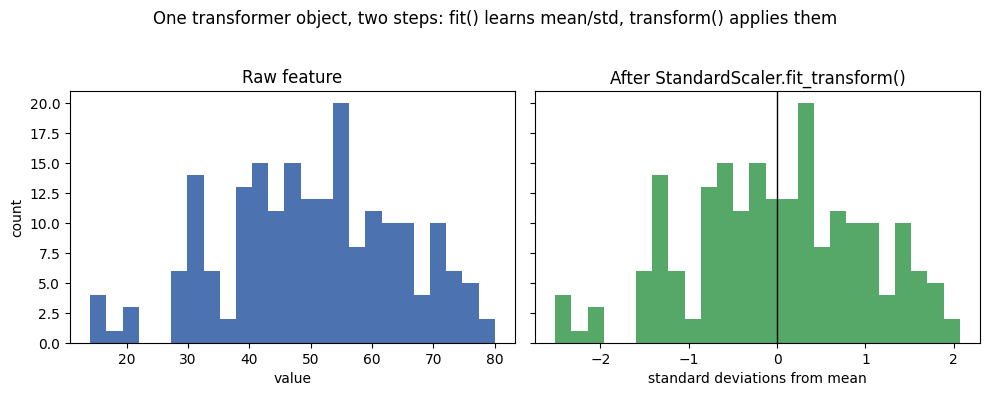

raw    mean/std : 50.2 / 14.4
scaled mean/std : 0.00 / 1.00   (≈ 0 / 1 — that's what the class learned)


In [16]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
raw    = rng.normal(50, 15, size=(200, 1))          # one feature: mean ~50, std ~15
scaled = StandardScaler().fit_transform(raw)        # our class, fit + transform in one call

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
axes[0].hist(raw.ravel(),    bins=25, color="#4C72B0"); axes[0].set(title="Raw feature", xlabel="value", ylabel="count")
axes[1].hist(scaled.ravel(), bins=25, color="#55A868"); axes[1].axvline(0, color="black", lw=1)
axes[1].set(title="After StandardScaler.fit_transform()", xlabel="standard deviations from mean")
fig.suptitle("One transformer object, two steps: fit() learns mean/std, transform() applies them", y=1.03)
plt.tight_layout(); plt.show()

print(f"raw    mean/std : {raw.mean():.1f} / {raw.std():.1f}")
print(f"scaled mean/std : {scaled.mean():.2f} / {scaled.std():.2f}   (≈ 0 / 1 — that's what the class learned)")


> **How to read it.** The shape is unchanged; only the axis moves — `fit()` learned this feature's mean and std, and `transform()` re-expressed every value as *"how many standard deviations from the mean."* Swap in `MinMaxScaler` and only the two overridden methods change.


### Pattern 3 — an estimator with `fit` / `predict`

Models follow the sibling convention: `.fit(X, y)` learns from labelled data; `.predict(X)` produces predictions. Here's the simplest possible model — a baseline that always predicts the mean of the training targets — written in the exact shape a real sklearn estimator uses.


In [17]:
class MeanRegressor:
    """A baseline model: predict the average training target for everything."""

    def fit(self, X, y):
        self.prediction_ = float(np.mean(y))   # the one thing it "learns"
        return self

    def predict(self, X):
        # one prediction per input row
        return np.full(len(X), self.prediction_)


X_train = [[1], [2], [3], [4]]
y_train = [10, 20, 30, 40]

model = MeanRegressor().fit(X_train, y_train)
print("learned mean:", model.prediction_)        # 25.0
print("predictions :", model.predict([[99], [100]]))   # [25. 25.]


learned mean: 25.0
predictions : [25. 25.]


**What the estimator actually predicts.** A picture of the `fit`/`predict` baseline: it learns one number (the training mean) and predicts it for every input.


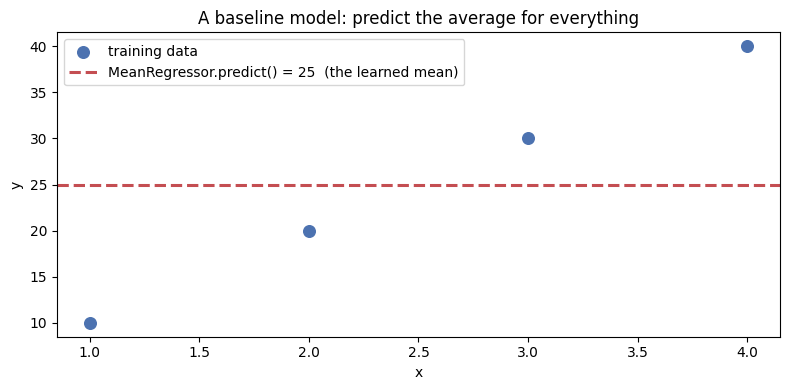

In [18]:
import matplotlib.pyplot as plt

xs = [row[0] for row in X_train]
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(xs, y_train, s=70, color="#4C72B0", zorder=3, label="training data")
ax.axhline(model.prediction_, color="#C44E52", lw=2.2, ls="--",
           label=f"MeanRegressor.predict() = {model.prediction_:.0f}  (the learned mean)")
ax.set(title="A baseline model: predict the average for everything", xlabel="x", ylabel="y")
ax.legend(); plt.tight_layout(); plt.show()


> **How to read it.** The flat red line is the model: it ignores `x` and returns the mean of `y`. Useless as a final model, but the *honest baseline* every real model must beat — and it already speaks the `fit`/`predict` language scikit-learn expects.


Every sklearn model — `LinearRegression`, `RandomForestClassifier`, `KMeans` — is a class with this same `fit` / `predict` shape. Because they all share the interface, you can swap one for another without changing the surrounding code:

```python
X_scaled = StandardScaler().fit_transform(X)   # preprocess
clf      = SomeClassifier().fit(X_scaled, y)   # train  — same .fit() everywhere
preds    = clf.predict(X_new)                  # use    — same .predict() everywhere
```

> 🧠 **Mental model.** "Estimator with `fit`/`predict`" and "transformer with `fit`/`transform`" are *conventions*, not language features — but because the whole ecosystem agrees on them, classes that follow the convention drop straight into pipelines, grid searches, and cross-validation. Writing your own helper as a class with the same method names is how you make it *feel native* to the data-science stack.


## 14. Common misconceptions — a quick reference

Keep this table handy; these four trip up almost everyone at first.

| ❌ Misconception | ✅ Correction |
|---|---|
| "A class *is* an object." | A class is a **blueprint**; the **instances** you build from it are the objects. |
| "Methods and functions are different things." | A **method is a function attached to an object** that auto-receives `self`. Same `def`, same rules. |
| "`super()` gives me inheritance." | Inheritance already exists from `class Child(Parent):`. `super()` only lets an **override reuse the parent's version**. |
| "A child automatically runs the parent's `__init__`." | Only if the child *doesn't* define its own. Once it does, you must call **`super().__init__(...)`** yourself. |

## 🧠 Mini-recap

- A **class** is a blueprint; an **instance** is a concrete thing built from the blueprint.
- `__init__(self, ...)` is the constructor. `self` is the current instance.
- **Instance attributes** (`self.x = …`) are per-instance; **class attributes** (in the class body) are shared by all instances — never make a *mutable* one by accident.
- **Methods** take `self`, can read/mutate attributes, and should call *other* methods on `self` to stay maintainable.
- **Inheritance** lets a subclass reuse a base class and override or extend it (`super()`); use it only for genuine *is-a* relationships.
- In data science, classes show up as **data wrappers** (`Dataset`, `DataFrame`) and as **`fit`/`transform`** and **`fit`/`predict`** objects — the building blocks of scikit-learn.


## 🧪 Practice exercises

Try each exercise yourself first. Solutions are right below — but you learn while struggling, not while reading the answer.

### Exercise 1 — ⭐ A `Person` class

Define a class `Person` with attributes `name` and `age`, and a method `greet()` that returns the string `"Hi, I'm <name> and I am <age> years old."`.

Create a `Person("Ada", 36)` and print `p.greet()`.

In [19]:
# Your code here  👇
class Person:
    ...

# p = Person("Ada", 36)
# print(p.greet())


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age  = age

    def greet(self):
        return f"Hi, I'm {self.name} and I am {self.age} years old."

p = Person("Ada", 36)
print(p.greet())
```

**Reasoning.** Three things to internalise. (1) `__init__` is the constructor — it assigns the arguments to `self.name` and `self.age`, which become *instance attributes*. (2) `greet(self)` takes `self` as its first parameter; Python supplies it automatically when you write `p.greet()`. (3) The f-string inside the method body uses `self.name`, not `name` — `name` alone would be an undefined local variable.
</details>

### Exercise 2 — ⭐⭐ A `BankAccount` with deposit and withdraw

Define a `BankAccount` class with attribute `balance` (default `0.0`) and two methods:

- `deposit(amount)` adds `amount` to the balance.
- `withdraw(amount)` subtracts `amount` from the balance **only if** the resulting balance would be ≥ 0;   otherwise it should print `"Insufficient funds"` and leave the balance unchanged.

Demonstrate both methods on a fresh account.

In [20]:
# Your code here  👇
class BankAccount:
    ...

# a = BankAccount()
# a.deposit(100); print(a.balance)
# a.withdraw(30); print(a.balance)
# a.withdraw(999); print(a.balance)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class BankAccount:
    def __init__(self, balance=0.0):
        self.balance = balance

    def deposit(self, amount):
        self.balance += amount

    def withdraw(self, amount):
        if self.balance - amount < 0:
            print("Insufficient funds")
            return
        self.balance -= amount

a = BankAccount()
a.deposit(100); print(a.balance)        # 100.0
a.withdraw(30); print(a.balance)        # 70.0
a.withdraw(999); print(a.balance)       # 'Insufficient funds' then 70.0
```

**Reasoning.** This exercise builds two habits. (1) **Default values in `__init__`** let callers leave out arguments — `BankAccount()` and `BankAccount(50.0)` both work. (2) **Guard at the top, mutate at the bottom.** The `if self.balance - amount < 0: return` shape is more readable than a nested `if/else`.
</details>

### Exercise 3 — ⭐⭐ Class attribute vs instance attribute

Define a `Circle` class where:

- `pi` is a **class attribute** equal to `3.14159` (shared by every circle).
- `radius` is an **instance attribute** set in `__init__`.
- `area()` returns `pi * radius ** 2` using `self.pi` and `self.radius`.

Create two circles with different radii and print each area. Then print `Circle.pi` to confirm it lives on the class.

In [21]:
# Your code here  👇
class Circle:
    ...

# c1 = Circle(1); c2 = Circle(2)
# print(c1.area(), c2.area())
# print(Circle.pi)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class Circle:
    pi = 3.14159                 # class attribute — one shared copy

    def __init__(self, radius):
        self.radius = radius     # instance attribute — per circle

    def area(self):
        return self.pi * self.radius ** 2

c1 = Circle(1); c2 = Circle(2)
print(c1.area(), c2.area())      # 3.14159 12.56636
print(Circle.pi)                 # 3.14159 — reachable on the class itself
```

**Reasoning.** `pi` is the same for every circle, so it belongs on the **class**, not duplicated into every instance. `radius` differs per circle, so it's an **instance** attribute. Inside `area()`, `self.pi` works because attribute lookup checks the instance first, then falls back to the class — so a constant defined once on the class is visible through every instance.
</details>

### Exercise 4 — ⭐⭐ Inheritance — `Shape`, `Rectangle`, `Square`

Build a small hierarchy:

- `Shape` is a base class with a method `area()` that does `raise NotImplementedError`.
- `Rectangle(Shape)` takes `width` and `height` in `__init__` and overrides `area()`.
- `Square(Rectangle)` takes a single `side` and reuses `Rectangle`'s `area()` by calling `super().__init__(side, side)`.

Confirm `Square(4).area()` returns `16`.

In [22]:
# Your code here  👇
class Shape:
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class Shape:
    def area(self):
        raise NotImplementedError("subclasses must implement area()")

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width  = width
        self.height = height
    def area(self):
        return self.width * self.height

class Square(Rectangle):
    def __init__(self, side):
        super().__init__(side, side)   # a square IS-A rectangle with equal sides

print(Rectangle(3, 4).area())   # 12
print(Square(4).area())         # 16 — inherits Rectangle.area() unchanged
```

**Reasoning.** `Square` writes **no** `area()` of its own — it inherits `Rectangle`'s. All it does is constrain construction (`side, side`) via `super().__init__`. This is the cleanest kind of inheritance: the subclass reuses the parent's behaviour wholesale and only specialises construction. Note the *is-a* chain reads correctly: a square is a rectangle is a shape.
</details>

## 🔮 Predict-the-output exercises

The fastest way to test your mental model: **predict what each cell prints *before* you run it.** Write your guess down, then run.

### Prediction 1 — class attribute vs instances

```python
class Counter:
    total = 0                 # class attribute — shared by all instances
    def __init__(self):
        Counter.total += 1

a = Counter(); b = Counter(); c = Counter()
print(Counter.total)
```
What does it print — `1` or `3`? Run the cell to check, then read the note.

In [23]:
class Counter:
    total = 0                 # class attribute — shared by all instances
    def __init__(self):
        Counter.total += 1

a = Counter(); b = Counter(); c = Counter()
print(Counter.total)


3


<details>
<summary>💡 <b>Answer</b></summary>

**`3`.** `total` is a **class attribute** — a single shared copy. Each `Counter()` runs `__init__`, which bumps the *one* shared counter. After three constructions it's `3`. (If `total` had been an *instance* attribute set with `self.total = 0`, each object would have its own and `Counter.total` wouldn't even exist.)
</details>

### Prediction 2 — overriding + dynamic dispatch

```python
class A:
    def hello(self):  return "A"
    def greet(self):  return "Hello from " + self.hello()

class B(A):
    def hello(self):  return "B"      # override only hello()

print(B().greet())
```
`greet()` is inherited from `A` and `A` never mentions `B` — so does `B().greet()` print `"Hello from A"` or `"Hello from B"`?

In [24]:
class A:
    def hello(self):  return "A"
    def greet(self):  return "Hello from " + self.hello()

class B(A):
    def hello(self):  return "B"      # override only hello()

print(B().greet())


Hello from B


<details>
<summary>💡 <b>Answer</b></summary>

**`Hello from B`.** This is *dynamic dispatch* (Section 9). `greet()` is inherited unchanged, but it calls `self.hello()` — and `self` is a `B`, so Python uses `B`'s overridden `hello()`. The parent's code automatically picks up the child's behaviour. This is *exactly* why PyTorch can define a training loop in the base class that calls *your* `forward()`.
</details>

## 🐞 Spot-the-bug exercises

Each snippet below is broken in a *classic* beginner way. Find the bug and write the fix in the empty cell — then check the solution.

### Bug 1 — what's wrong here?

```python
class Dog:
    def __init__(name, sound):     # 🐞
        self.name  = name
        self.sound = sound

rex = Dog("Rex", "Woof")
```

In [25]:
# Your corrected version here  👇


<details>
<summary>💡 <b>Solution</b></summary>

**The first parameter `self` is missing.** Python always passes the new object in as the first argument; with no `self` to catch it, `Dog("Rex", "Woof")` raises `TypeError: __init__() takes 2 positional arguments but 3 were given`.

```python
class Dog:
    def __init__(self, name, sound):   # ✅ self first
        self.name  = name
        self.sound = sound

rex = Dog("Rex", "Woof")
print(rex.name, rex.sound)             # Rex Woof
```
*Whenever you see "takes N arguments but N+1 were given" on construction, suspect a missing `self`.*
</details>

### Bug 2 — why does `s.balance` blow up?

```python
class Account:
    def __init__(self, owner):
        self.owner   = owner
        self.balance = 0.0

class Savings(Account):
    def __init__(self, owner, rate):    # 🐞
        self.rate = rate

s = Savings("Ada", 0.05)
print(s.balance)                        # AttributeError!
```

In [26]:
# Your corrected version here  👇


<details>
<summary>💡 <b>Solution</b></summary>

**`Savings` defines its own `__init__` but never calls the parent's**, so `self.owner` and `self.balance` are never created (Section 11). Add `super().__init__(owner)` as the first line:

```python
class Savings(Account):
    def __init__(self, owner, rate):
        super().__init__(owner)    # ✅ run Account.__init__ first
        self.rate = rate

s = Savings("Ada", 0.05)
print(s.owner, s.balance, s.rate)  # Ada 0.0 0.05
```
</details>

## ♻️ Refactoring exercise — from dict + functions to a class

Go full circle. Below is the **Section 1** code: a customer dict plus three free-standing functions. **Refactor it into a single `Customer` class** with attributes `name`, `monthly_revenue`, `is_active` and methods `annual_revenue()`, `deactivate()`, and `is_high_value(threshold=10_000)`. Then create a customer and call each method.

```python
customer = {"name": "Acme Inc.", "monthly_revenue": 14823.46, "is_active": True}

def annual_revenue(c):              return c["monthly_revenue"] * 12
def deactivate(c):                  c["is_active"] = False
def is_high_value(c, t=10_000):     return c["monthly_revenue"] >= t
```

This is the exercise that makes the *motivation* for OOP stick — you feel the data and behaviour snap together.

In [27]:
# Your Customer class here  👇
class Customer:
    ...


<details>
<summary>💡 <b>Solution</b></summary>

```python
class Customer:
    def __init__(self, name, monthly_revenue, is_active=True):
        self.name            = name
        self.monthly_revenue = monthly_revenue
        self.is_active       = is_active

    def annual_revenue(self):
        return self.monthly_revenue * 12

    def deactivate(self):
        self.is_active = False

    def is_high_value(self, threshold=10_000):
        return self.monthly_revenue >= threshold

acme = Customer("Acme Inc.", 14_823.46)
print(acme.annual_revenue())   # 177881.52
print(acme.is_high_value())    # True
acme.deactivate()
print(acme.is_active)          # False
```

**What changed and why it's better.** The three loose functions became **methods**, and the three dict keys became **attributes** set once in `__init__`. Now the data and the behaviour travel together: there's one place that defines what a customer *is* and what it *can do*, the `customer["..."]` string-key typos are gone, and adding a new behaviour means adding a method — not another free function floating somewhere else.
</details>

## 🧠 Stretch exercises

Two deeper exercises that tie classes to data science. Try them yourself before opening the solution.

### Stretch exercise C — ⭐⭐⭐ An `Order` with line items

Build an `Order` class that supports:

- An empty order at construction (`self.items = []` — *not* a mutable default argument).
- `add_item(name, price, qty)` — appends a line item (store each as a dict).
- `total()` — returns the sum of `price * qty` across all items.
- `describe()` — returns a string like `"Order: 2 items, total $49.47"` that **reuses** `total()`.

In [28]:
# Your code here  👇
class Order:
    ...

# o = Order()
# o.add_item("widget", 9.99, 3)
# o.add_item("gadget", 19.50, 1)
# print(o.describe())     # Order: 2 items, total $49.47


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
class Order:
    def __init__(self):
        self.items = []   # one fresh list per instance — NOT a mutable default arg

    def add_item(self, name, price, qty):
        self.items.append({"name": name, "price": price, "qty": qty})

    def total(self):
        return sum(item["price"] * item["qty"] for item in self.items)

    def describe(self):
        return f"Order: {len(self.items)} items, total ${self.total():.2f}"

o = Order()
o.add_item("widget", 9.99, 3)
o.add_item("gadget", 19.50, 1)
print(o.describe())     # Order: 2 items, total $49.47
```

**Reasoning.** Two important habits. (1) **`self.items = []` inside `__init__`** — *never* `def __init__(self, items=[])`. The latter shares one list across every instance, the same trap as a mutable class attribute (Section 4). (2) **Reuse your own methods** — `describe()` calls `self.total()` instead of recomputing the sum, so the formatting stays consistent if `total()` ever changes.
</details>

### Stretch exercise D — ⭐⭐⭐ A `Standardizer` transformer (data science)

Re-implement a one-column standardizer in the scikit-learn `fit`/`transform` style, inheriting the `fit_transform` convenience method from a base class:

- `BaseTransformer` has `fit`, `transform` (both `raise NotImplementedError`) and a concrete `fit_transform(X)` that calls `self.fit(X)` then `self.transform(X)`.
- `Standardizer(BaseTransformer)` overrides `fit(X)` to store `self.mean_` and `self.std_` (use the `statistics` module or plain Python), and `transform(X)` to return `[(x - mean) / std for x in X]`.

Confirm that `Standardizer().fit_transform([10, 20, 30])` is centred on 0.

In [29]:
# Your code here  👇
class BaseTransformer:
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import statistics

class BaseTransformer:
    def fit(self, X):
        raise NotImplementedError
    def transform(self, X):
        raise NotImplementedError
    def fit_transform(self, X):          # written once — inherited by every subclass
        self.fit(X)
        return self.transform(X)

class Standardizer(BaseTransformer):
    def fit(self, X):
        self.mean_ = statistics.mean(X)          # learned params: trailing _
        self.std_  = statistics.pstdev(X)
        return self
    def transform(self, X):
        return [(x - self.mean_) / self.std_ for x in X]

print(Standardizer().fit_transform([10, 20, 30]))   # [-1.2247..., 0.0, 1.2247...]
```

**Reasoning.** This is the real scikit-learn shape in miniature. (1) **`fit` learns and stores** parameters on `self` with a trailing-underscore name (`mean_`, `std_`) — the library-wide convention for "computed during fit". (2) **`transform` only uses** those stored params, so you can `fit` on training data and `transform` test data with the *same* learned numbers. (3) **`fit_transform` is inherited**, written once in the base — add ten more transformers and none of them re-implement it. That single shared method is exactly what `TransformerMixin` gives real sklearn classes.
</details>

## 🧠 Key takeaways

- A class bundles **data + behaviour**; `__init__(self, …)` is the constructor and `self` is the current instance.
- **Instance attributes** are per-object; **class attributes** are shared — keep mutable state per-instance.
- **Methods** use `self` and should call one another to stay DRY and maintainable.
- **Inheritance** reuses a base class and overrides/extends it (`super()`) — for genuine *is-a* relationships only.
- The data-science stack is classes all the way down: **wrappers** like `Dataset`/`DataFrame`, and the **`fit`/`transform`** + **`fit`/`predict`** conventions that power scikit-learn.

## 🚀 Next step

→ **`06_pandas_fundamentals.ipynb`** — DataFrames are objects you instantiate and call methods on. Everything you just learned applies directly.
